## Среднее и СКО для вероятностей попадания оружия

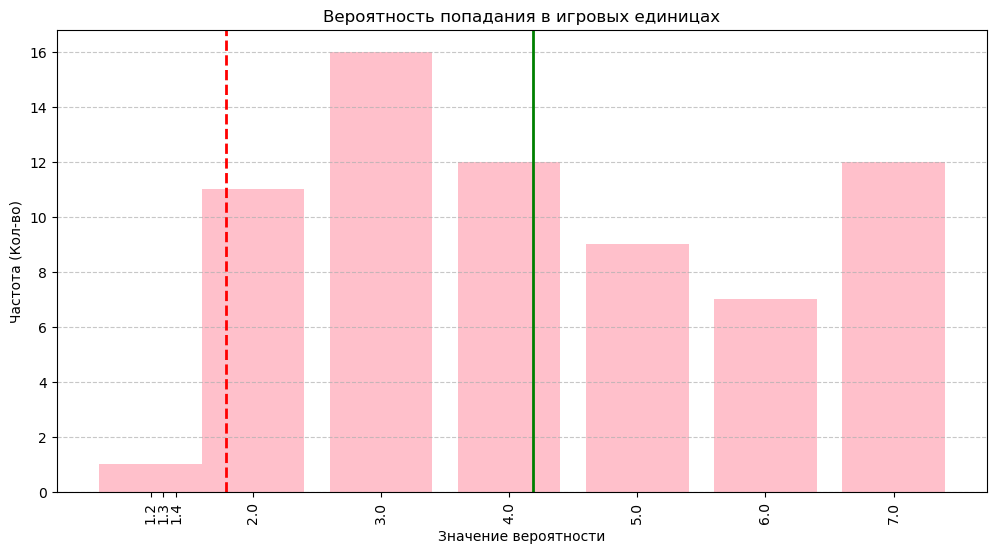

In [18]:
import numpy as np
import gspread
import matplotlib.pyplot as plt
from collections import Counter
import numpy as np

# Авторизация через Google API
gc = gspread.service_account(filename='unitydatascience-444800-224a4221205f.json')

# Открываем табличку по её имени
sh = gc.open('Week#3 - Баланс в играх')

# Открываем лист
worksheet = sh.worksheet('BigDigital GameLab')

# Получаем данные из нужных колонок (E27:N33)
damage_cells = worksheet.range('E27:N33')

# Преобразуем данные в числа
damage_values = []
for cell in damage_cells:
    try:
        value = float(cell.value.replace(',', '.')) if cell.value else 7
        damage_values.append(value)
    except ValueError:
        damage_values.append(0)

# Вычисляем стандартное отклонение (СКО)
mean_value = np.mean(damage_values)

# Вычисляем среднее
std_dev = np.std(damage_values)

# Подсчитайте частоту для разных вероятностей
value_counts = Counter(damage_values)
values = list(value_counts.keys())
counts = list(value_counts.values())

# Сортируйте значения и их количество для более структурированного графика
sorted_indices = np.argsort(values)
values = np.array(values)[sorted_indices]
counts = np.array(counts)[sorted_indices]

# Строим гистограмму
plt.figure(figsize=(12, 6))
plt.bar(values, counts, color='pink', width=0.8)

# Линия среднего значения
plt.axvline(x=mean_value, color='green', linestyle='-', linewidth=2, label=f'Среднее = {mean_value:.2f}')

# Линия СКО
plt.axvline(x=std_dev, color='red', linestyle='--', linewidth=2, label=f'СКО = {std_dev:.2f}')

plt.xlabel('Значение вероятности')
plt.ylabel('Частота (Кол-во)')
plt.title('Вероятность попадания в игровых единицах')
plt.xticks(values, rotation=90)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


## График разброса урона оружия

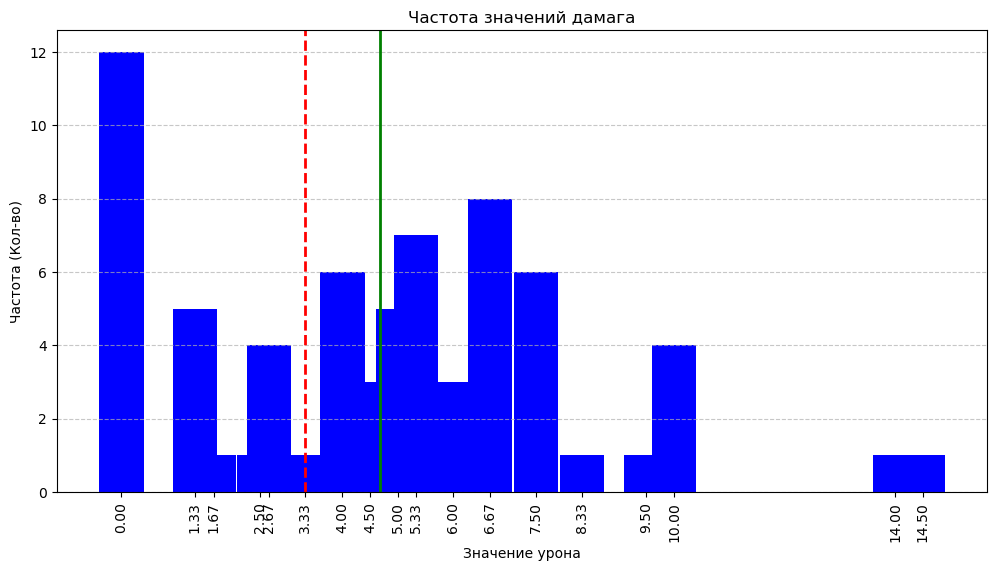

In [19]:
# Получаем данные из нужных колонок (AA27 to AJ33)
damage_columns = worksheet.range('AA27:AJ33')

# Преобразуем данные в числа
damage_values = [float(cell.value.replace(',', '.')) for cell in damage_columns]

# Вычисляем стандартное отклонение (СКО)
mean_value = np.mean(damage_values)

# Вычисляем среднее
std_dev = np.std(damage_values)

# Подсчитайте частоту каждого уникального дамага
value_counts = Counter(damage_values)
values = list(value_counts.keys())
counts = list(value_counts.values())

# Сортируйте значения и их количество для более структурированного графика
sorted_indices = np.argsort(values)
values = np.array(values)[sorted_indices]
counts = np.array(counts)[sorted_indices]

# Строим гистограмму
plt.figure(figsize=(12, 6))
plt.bar(values, counts, color='blue', width=0.8)

# Линия среднего значения
plt.axvline(x=mean_value, color='green', linestyle='-', linewidth=2, label=f'Среднее = {mean_value:.2f}')

# Линия СКО
plt.axvline(x=std_dev, color='red', linestyle='--', linewidth=2, label=f'СКО = {std_dev:.2f}')

plt.xlabel('Значение урона')
plt.ylabel('Частота (Кол-во)')
plt.title('Частота значений дамага')
plt.xticks(values, rotation=90)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


#### Данных, содержащих время отклика игроков нет, используем рандом

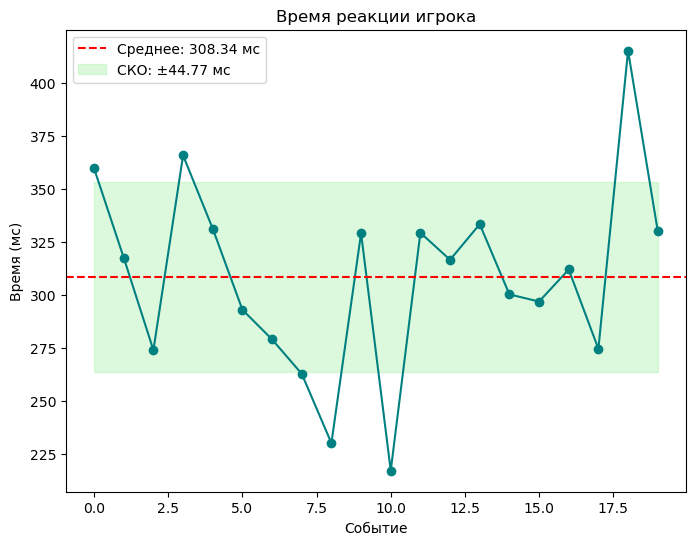

In [20]:
reaction_times = np.random.normal(loc=300, scale=50, size=20)  # Среднее время = 300 мс

plt.figure(figsize=(8, 6))
plt.plot(reaction_times, 'o-', color='teal')
plt.axhline(reaction_times.mean(), color='red', linestyle='dashed', label=f'Среднее: {reaction_times.mean():.2f} мс')
plt.fill_between(range(20),
                 reaction_times.mean() - np.std(reaction_times),
                 reaction_times.mean() + np.std(reaction_times),
                 color='lightgreen', alpha=0.3, label=f'СКО: ±{np.std(reaction_times):.2f} мс')
plt.legend()
plt.title('Время реакции игрока')
plt.xlabel('Событие')
plt.ylabel('Время (мс)')
plt.show()